<a href="https://colab.research.google.com/github/minndao/Soulboy/blob/main/WIA1006_Machine_Learning_Group_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Data Preprocessing

In [ ]:
import os
import pandas as pd

PATH_FILE = "/content/drive/MyDrive/WIA1006 Machine Learning Group Assignment"
dataset_path = os.path.join(PATH_FILE, "dating_app_behavior_dataset_extended.csv")
df = pd.read_csv(dataset_path)

In [ ]:
df.head()

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,...,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome,age,height_cm,weight_kg,zodiac_sign,body_type,relationship_intent
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,...,0.36,13,Early Morning,Mutual Match,56,149,40.6,Taurus,Curvy,Friends Only
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,...,0.42,0,Morning,Chat Ignored,40,155,69.7,Leo,Plus Size,Hookups
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,...,0.41,1,After Midnight,Date Happened,30,185,96.9,Sagittarius,Curvy,Serious Relationship
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,...,0.07,21,Morning,No Action,57,154,49.3,Taurus,Slim,Exploring
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,...,0.11,22,After Midnight,One-sided Like,24,149,40.0,Libra,Slim,Casual Dating


In [ ]:
df.shape

(50000, 25)

In [ ]:
# Dropping duplicates (if any)
df.drop_duplicates(inplace = True)

In [ ]:
df.shape

(50000, 25)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         50000 non-null  object 
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  object 
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  object 
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int64  
 15  emoji_usage_rate   

In [ ]:
numerical_cols = []

for col in df.columns:
    if df[col].dtype == 'int64' or df[col].dtype == 'float64':
        numerical_cols.append(col)

print(numerical_cols)

['app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'age', 'height_cm', 'weight_kg']


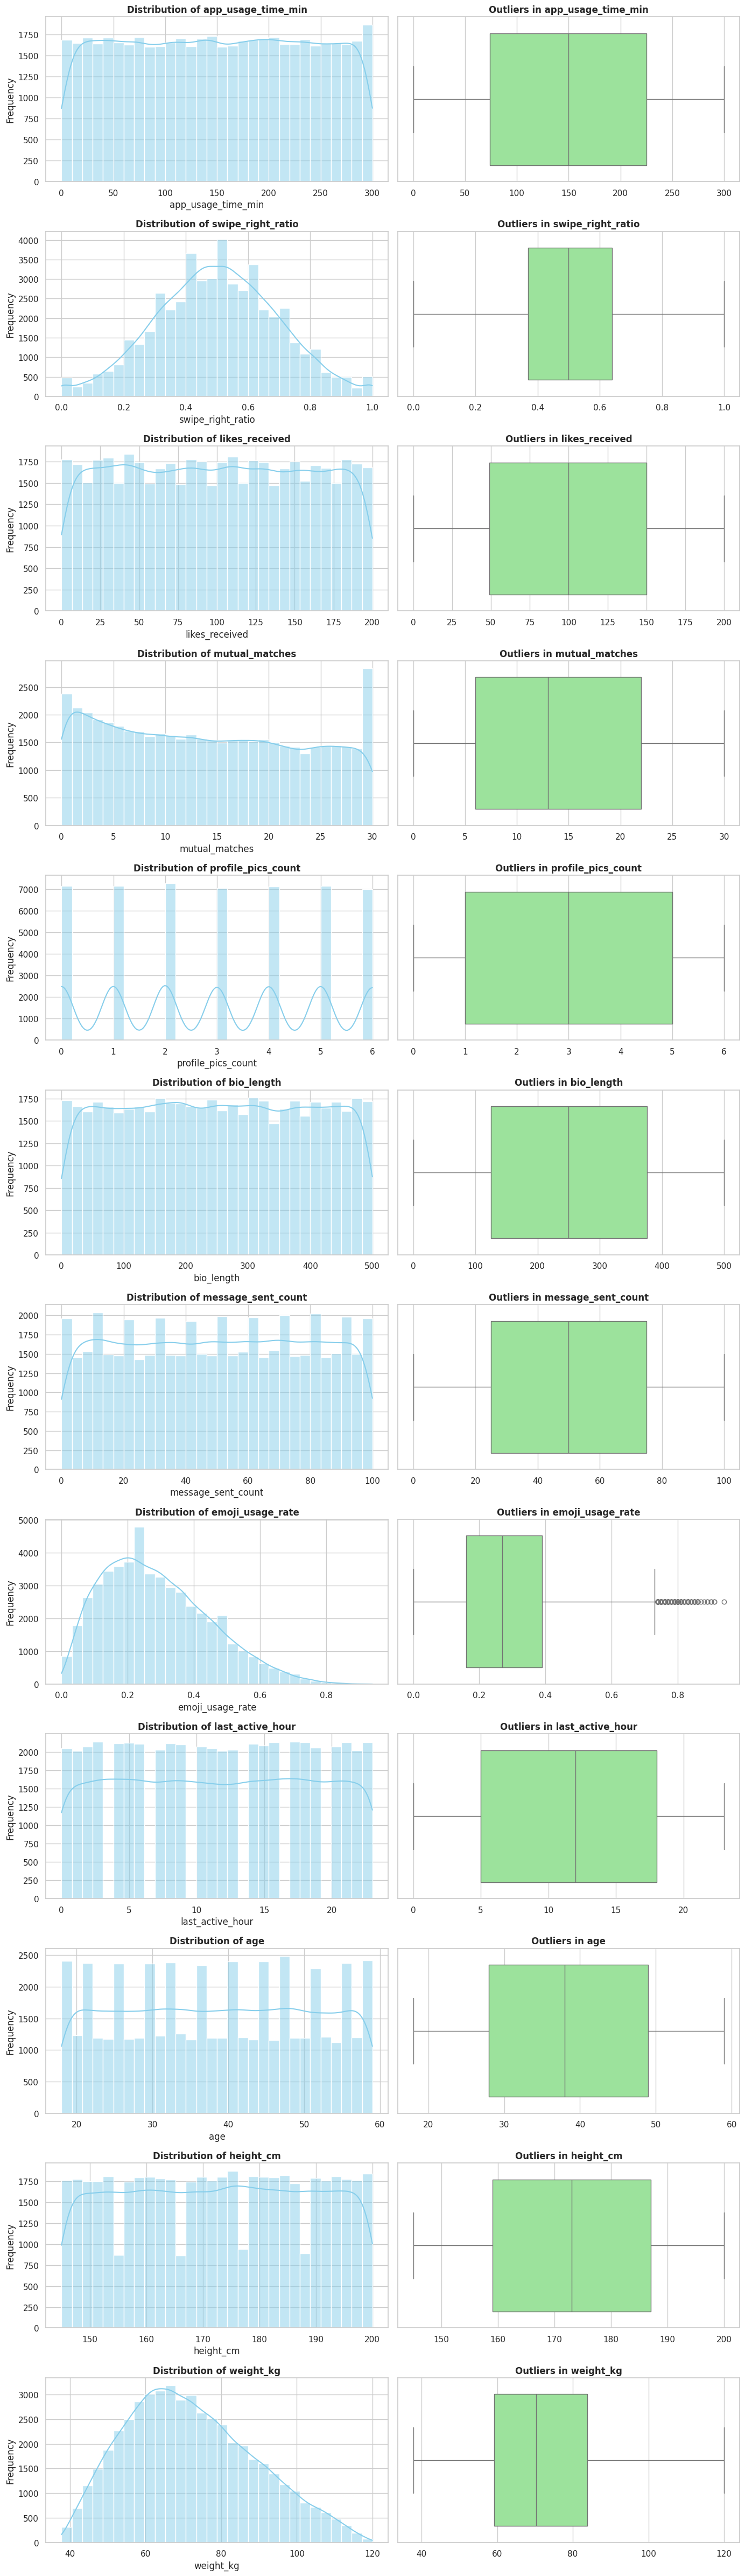

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=2, figsize=(14, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):

    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue', bins=30)
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Frequency')

    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, MultiLabelBinarizer

# Drop textual labels to avoid multicollinearity
df = df.drop(columns=['app_usage_time_label', 'swipe_right_label'], errors='ignore')

In [ ]:
# ==========================================
# 2. MANUAL FEATURE ENGINEERING
# ==========================================
# MultiLabelBinarizer for High-Cardinality 'interest_tags'
mlb = MultiLabelBinarizer()
df['interest_tags'] = df['interest_tags'].fillna('')
interests_list = df['interest_tags'].apply(lambda x: [tag.strip() for tag in x.split(',')])

# Create binary columns and drop the original text column
df_interests = pd.DataFrame(mlb.fit_transform(interests_list), columns=[f"interest_{c}" for c in mlb.classes_], index=df.index)
df = pd.concat([df, df_interests], axis=1).drop(columns=['interest_tags'])

In [ ]:
# Cyclic Transformation
df['last_active_hour_sin'] = np.sin(2 * np.pi * df['last_active_hour'] / 24)
df['last_active_hour_cos'] = np.cos(2 * np.pi * df['last_active_hour'] / 24)
df = df.drop(columns=['last_active_hour'])

In [ ]:
# Capping Outliers
cols_to_cap = ['app_usage_time_min', 'message_sent_count', 'likes_received', 'mutual_matches']
for col in cols_to_cap:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

In [ ]:
# ==========================================
# 3. SKLEARN COLUMN TRANSFORMER
# ==========================================
# Define column groups
ordinal_cols = ['education_level', 'income_bracket']
nominal_cols = ['gender', 'sexual_orientation', 'location_type', 'body_type', 'relationship_intent', 'swipe_time_of_day', 'zodiac_sign']

# Include all remaining numeric columns for scaling
numeric_cols = df.select_dtypes(include=['number']).columns.drop('match_outcome', errors='ignore').tolist()
# Exclude newly created binary interest columns from being scaled
numeric_cols = [col for col in numeric_cols if not col.startswith('interest_')]

# Define hierarchy for Ordinal Encoder
education_order = ['No Formal Education', 'High School', 'Diploma', 'Associate’s', 'Bachelor’s', 'Master’s', 'MBA', 'PhD', 'Postdoc']
income_order = ['Very Low', 'Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High', 'Very High']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[education_order, income_order]), ordinal_cols),
        ('nominal', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nominal_cols),
        ('scaler', RobustScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) and Target (y)
X = df.drop(columns=['match_outcome'])
y = df['match_outcome']

# 2. Perform Train-Test Split (70% Training, 30% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Original dataset shape: {X.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

# ==========================================
# 3. APPLY PREPROCESSOR
# ==========================================
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get the new column names back
new_nominal_cols = preprocessor.named_transformers_['nominal'].get_feature_names_out(nominal_cols)
all_new_cols = ordinal_cols + list(new_nominal_cols) + numeric_cols + [col for col in X.columns if col.startswith('interest_')]

X_train_final = pd.DataFrame(X_train_processed, columns=all_new_cols, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed, columns=all_new_cols, index=X_test.index)

print("\nData is split and processed")

Original dataset shape: (50000, 71)
Training set shape: (35000, 71)
Testing set shape:  (15000, 71)

Data is split and processed


In [ ]:
X_train_final

,education_level,income_bracket,gender_Female,gender_Genderfluid,gender_Male,gender_Non-binary,gender_Prefer Not to Say,gender_Transgender,sexual_orientation_Asexual,sexual_orientation_Bisexual,...,interest_Sneaker Culture,interest_Social Activism,interest_Spirituality,interest_Stand-up Comedy,interest_Startups,interest_Tattoos,interest_Tech,interest_Traveling,interest_Writing,interest_Yoga
3298,6.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34114,4.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47082,3.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
33331,7.0,6.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45250,0.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34773,3.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2981,1.0,6.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5983,6.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43802,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 3298 to 33825
Columns: 114 entries, education_level to interest_Yoga
dtypes: float64(114)
memory usage: 30.7 MB


In [ ]:
# ==========================================
# FEATURE SELECTION & EXTRACTION
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Encode the Target Label
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Match outcome classes:", le.classes_)

Match outcome classes: ['Blocked' 'Catfished' 'Chat Ignored' 'Date Happened' 'Ghosted'
 'Instant Match' 'Mutual Match' 'No Action' 'One-sided Like'
 'Relationship Formed']


In [ ]:
# Drop any column where variance is below 0.01
selector_var = VarianceThreshold(threshold=0.1)
X_train_var = selector_var.fit_transform(X_train_final)
X_test_var = selector_var.transform(X_test_final)

# Get the names of columns that survived
cols_after_var = X_train_final.columns[selector_var.get_support()]

print(f"Before: {X_train_final.shape[1]} features")
print(f"After variance filter: {X_train_var.shape[1]} features")
print(f"Dropped: {X_train_final.shape[1] - X_train_var.shape[1]} features")

Before: 114 features
After variance filter: 53 features
Dropped: 61 features


In [ ]:
is_discrete = np.array([
    len(np.unique(X_train_var[:,i])) <= 2
    for i in range(X_train_var.shape[1])
])

print(f"Continuous features: {sum(~is_discrete)}")
print(f"Discrete features: {sum(is_discrete)}")

Continuous features: 15
Discrete features: 38


In [ ]:
print(X_train_var.shape)
print(X_test_var.shape)

(35000, 53)
(15000, 53)


In [ ]:
# Keep the top 30 features for x after mutual information
selector_mi = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(
        X, y, discrete_features=is_discrete, random_state=42
    ), k=30
)

X_train_mi = selector_mi.fit_transform(X_train_var, y_train_encoded)
X_test_mi = selector_mi.transform(X_test_var)

# Convert column from Index to list
cols_after_var_list = list(cols_after_var)

# Creating a panda Series that pair each score with its column name
mi_scores = pd.Series(selector_mi.scores_, index=cols_after_var_list)

# Keep the top 30 most useful column and convert it to list
top30_cols = mi_scores.nlargest(30).index.tolist()

print("Scores by Mutual Information:")
print(mi_scores.nlargest(30))




Scores by Mutual Information:
age                                 0.007708
mutual_matches                      0.006240
emoji_usage_rate                    0.002297
bio_length                          0.002281
last_active_hour_cos                0.000663
gender_Non-binary                   0.000267
gender_Genderfluid                  0.000225
gender_Prefer Not to Say            0.000220
location_type_Suburban              0.000218
sexual_orientation_Straight         0.000212
gender_Female                       0.000204
location_type_Urban                 0.000198
swipe_time_of_day_Afternoon         0.000179
body_type_Athletic                  0.000170
sexual_orientation_Demisexual       0.000154
sexual_orientation_Gay              0.000148
relationship_intent_Networking      0.000142
location_type_Remote Area           0.000141
swipe_time_of_day_Late Night        0.000128
body_type_Muscular                  0.000125
sexual_orientation_Bisexual         0.000124
relationship_intent_Explo

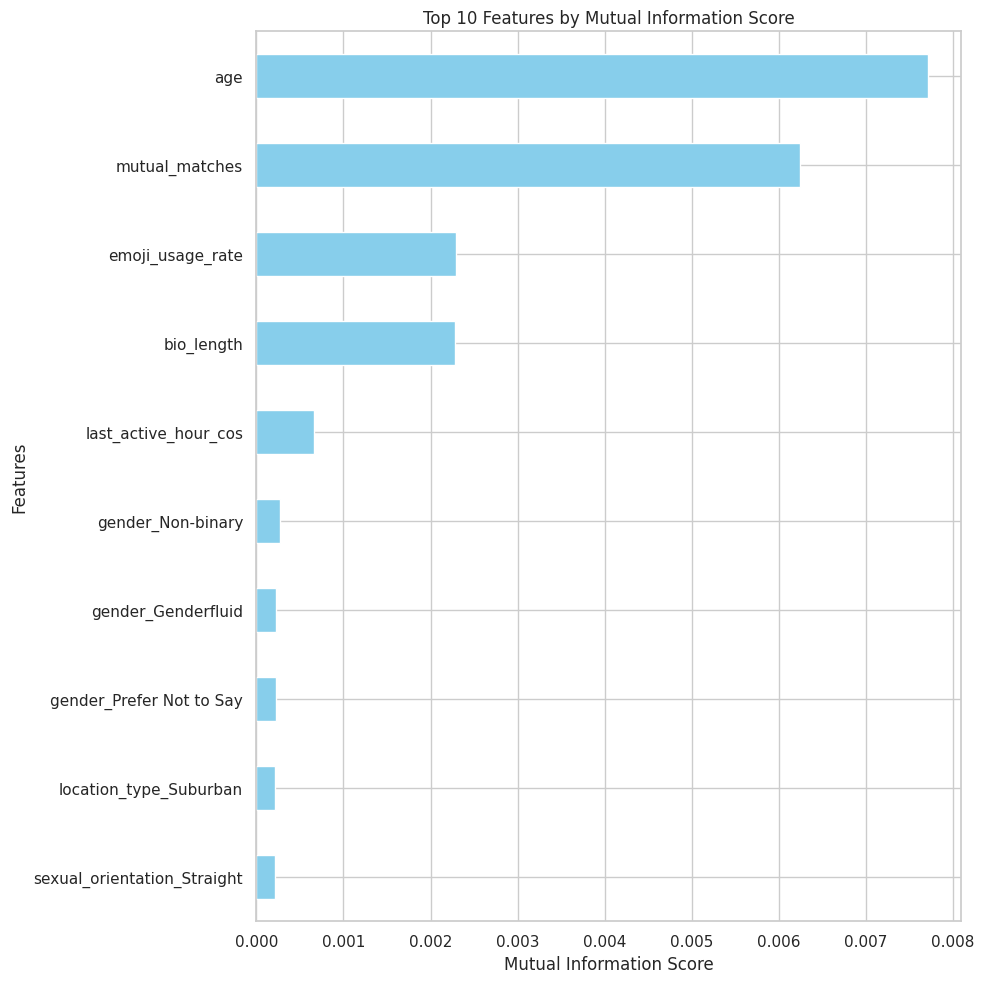

In [ ]:
# Visuallizing the Data afte MI
plt.figure(figsize=(10,10))
mi_scores.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Features by Mutual Information Score')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# Train it
rf.fit(X_train_mi, y_train_encoded)

# Get importance score
importances = pd.Series(rf.feature_importances_, index=top30_cols)
importances_sorted = importances.sort_values(ascending=False)

print("Top 10 Features by Random Forest Importance: ")
print(importances_sorted.head(10))

Top 10 Features by Random Forest Importance: 
body_type_Slim                  0.137700
sexual_orientation_Queer        0.122605
location_type_Metro             0.108090
gender_Male                     0.105193
swipe_time_of_day_Evening       0.090198
sexual_orientation_Gay          0.021058
swipe_time_of_day_Late Night    0.020718
sexual_orientation_Bisexual     0.020440
location_type_Remote Area       0.020122
body_type_Muscular              0.020036
dtype: float64


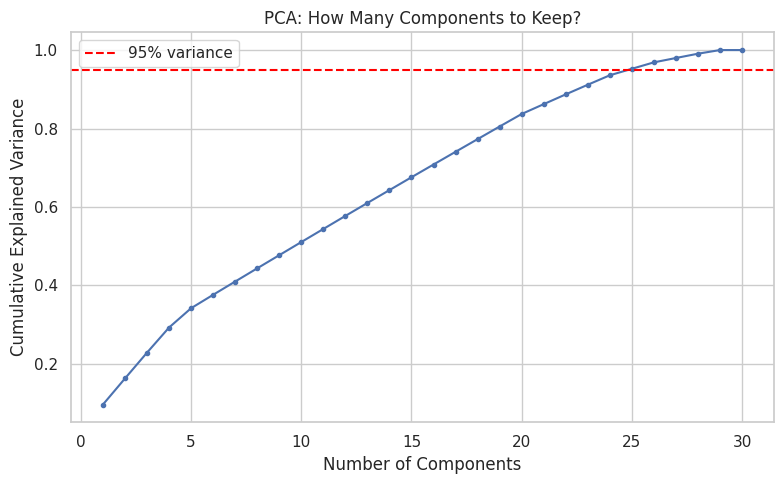

Components needed to explain 95% variance: 25
Before PCA: 30 features
After PCA: 25 features
Variance retained: 0.9522


In [ ]:
# PCA
pca_explorer = PCA(random_state=42)

# Study the data
pca_explorer.fit(X_train_mi)
cumVar = np.cumsum(pca_explorer.explained_variance_ratio_)

# Visualize the result
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumVar)+1),cumVar,marker='o', markersize=3)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: How Many Components to Keep?')
plt.legend()
plt.tight_layout()
plt.show()

# Finding the components needed
n_components_at_95 = np.argmax(cumVar >= 0.95) + 1
print(f"Components needed to explain 95% variance: {n_components_at_95}")

# Apply PCA for real
pca = PCA( n_components=n_components_at_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_mi)
X_test_pca = pca.transform(X_test_mi)

# Result of PCA
print(f"Before PCA: {X_train_mi.shape[1]} features")
print(f"After PCA: {X_train_pca.shape[1]} features")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")

In [ ]:
# So now got 2 options,
# Option 1 - Use the MI selected features (30 columns, still have names)
X_trained_mi_pd = pd.DataFrame(X_train_mi, columns=top30_cols)
X_test_mi_pd = pd.DataFrame(X_test_mi, columns=top30_cols)
print("Option 1 shape: ",X_trained_mi_pd.shape)

# Option 2 - Use the PCA compressed features (25 columns, but no names for them)
X_trained_pca_pd = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(25)])
X_test_pca_pd = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(25)])
print("Option 2 shape: ",X_trained_pca_pd.shape)

# I recommend using Option 1 cause not much features being compressed after PCA

Option 1 shape:  (35000, 30)
Option 2 shape:  (35000, 25)


--- Class Distribution Report ---
                     Count  Percentage (%)
match_outcome                             
One-sided Like        5112          10.224
Instant Match         5078          10.156
Blocked               5049          10.098
Catfished             5025          10.050
Chat Ignored          5019          10.038
Mutual Match          4990           9.980
No Action             4986           9.972
Ghosted               4959           9.918
Date Happened         4919           9.838
Relationship Formed   4863           9.726


/tmp/ipykernel_8416/1775756879.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


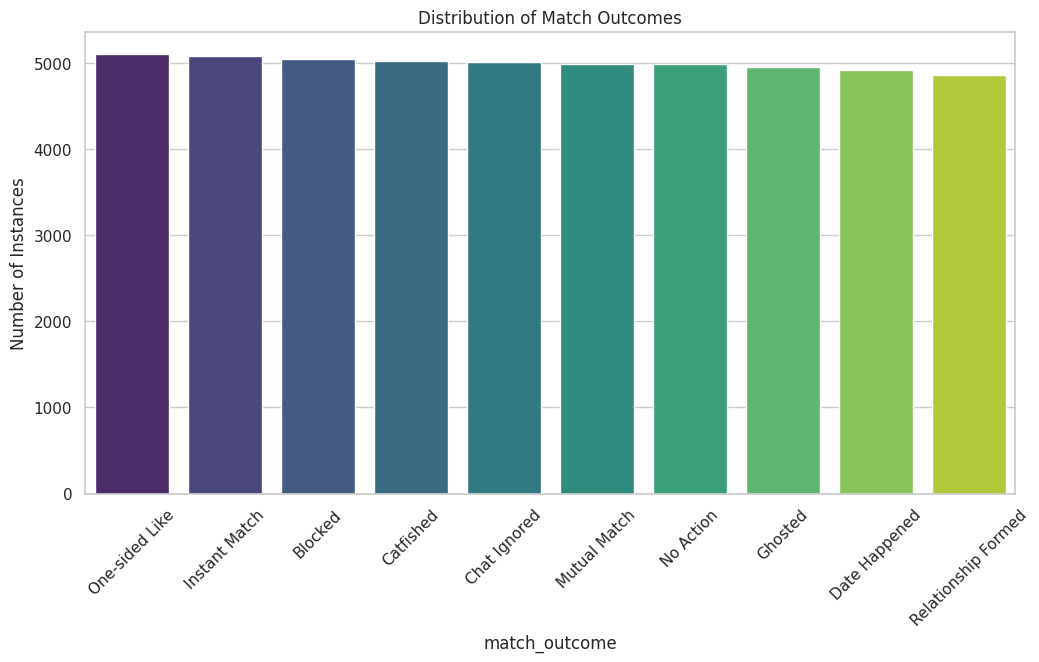

In [ ]:
# 1. Get raw counts and percentages
counts = df['match_outcome'].value_counts()
percent = df['match_outcome'].value_counts(normalize=True) * 100

# 2. Combine into a nice summary table
imbalance_report = pd.DataFrame({'Count': counts, 'Percentage (%)': percent})
print("--- Class Distribution Report ---")
print(imbalance_report)

# 3. Quick visualization (Crucial for 10 classes)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Distribution of Match Outcomes')
plt.xticks(rotation=45)
plt.ylabel('Number of Instances')
plt.show()

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import pandas as pd

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import time

In [ ]:
def run_model_comparison(X_train, y_train, X_test, y_test, target_names):
    # Define models and their search spaces
    model_configs = {
        "Random Forest": {
            "model": RandomForestClassifier(random_state=42),
            "params": {
                "n_estimators": [100, 300, 500],
                "max_depth": [10, 20, 30, None],
                "min_samples_split": [2, 5, 10]
            }
        },
        "XGBoost": {
            "model": XGBClassifier(eval_metric='mlogloss', random_state=42),
            "params": {
                "n_estimators": [100, 200],
                "learning_rate": [0.01, 0.1, 0.2],
                "max_depth": [3, 6, 9],
                "subsample": [0.8, 1.0]
            }
        },
        "LightGBM": {
            "model": LGBMClassifier(random_state=42, verbosity=-1),
            "params": {
                "n_estimators": [100, 300],
                "learning_rate": [0.01, 0.1],
                "num_leaves": [31, 60, 127]
            }
        },
        "Extra Trees": {
            "model": ExtraTreesClassifier(random_state=42),
            "params": {
                "n_estimators": [100, 300],
                "max_depth": [10, 30, None],
                "min_samples_split": [2, 10]
            }
        },
        "Gradient Boosting": {
            "model": GradientBoostingClassifier(random_state=42),
            "params": {
                "n_estimators": [100, 200],
                "learning_rate": [0.05, 0.1],
                "max_depth": [3, 5]
            }
        },
        "Logistic Regression": { # Good baseline for balanced data
            "model": LogisticRegression(max_iter=1000, random_state=42),
            "params": {
                "C": [0.1, 1, 10],
                "solver": ['lbfgs', 'saga']
            }
        }
    }

    leaderboard = []
    best_models = {}

    for name, config in model_configs.items():
        print(f"--- Tuning {name} ---")
        start_time = time.time()

        # Randomized search for efficiency
        search = RandomizedSearchCV(
            config['model'],
            config['params'],
            n_iter=10,
            cv=3,
            scoring='f1_macro',
            n_jobs=-1,
            random_state=42
        )

        search.fit(X_train, y_train)
        elapsed = time.time() - start_time

        # Evaluate on test set
        y_pred = search.best_estimator_.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        acc = accuracy_score(y_test, y_pred)

        leaderboard.append({
            "Model": name,
            "Best F1 (Macro)": f1,
            "Accuracy": acc,
            "Time (s)": round(elapsed, 2)
        })

        best_models[name] = search.best_estimator_
        print(f"{name} Done. F1: {f1:.4f}")

    return pd.DataFrame(leaderboard).sort_values(by="Best F1 (Macro)", ascending=False), best_models

In [ ]:
results_df, trained_models = run_model_comparison(X_trained_mi_pd, y_train_encoded, X_test_mi_pd, y_test_encoded, le.classes_)
print("\n--- Final Leaderboard ---")
print(results_df)

--- Tuning Random Forest ---
Random Forest Done. F1: 0.0982
--- Tuning XGBoost ---
XGBoost Done. F1: 0.0961
--- Tuning LightGBM ---
LightGBM Done. F1: 0.0997
--- Tuning Extra Trees ---
Extra Trees Done. F1: 0.0991
--- Tuning Gradient Boosting ---


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Gradient Boosting Done. F1: 0.0979
--- Tuning Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Logistic Regression Done. F1: 0.0993

--- Final Leaderboard ---
                 Model  Best F1 (Macro)  Accuracy  Time (s)
2             LightGBM         0.099721  0.099800    324.07
5  Logistic Regression         0.099270  0.102467     57.84
3          Extra Trees         0.099063  0.099067    235.36
0        Random Forest         0.098201  0.098733    428.78
4    Gradient Boosting         0.097905  0.099133   1656.29
1              XGBoost         0.096056  0.096067    211.52


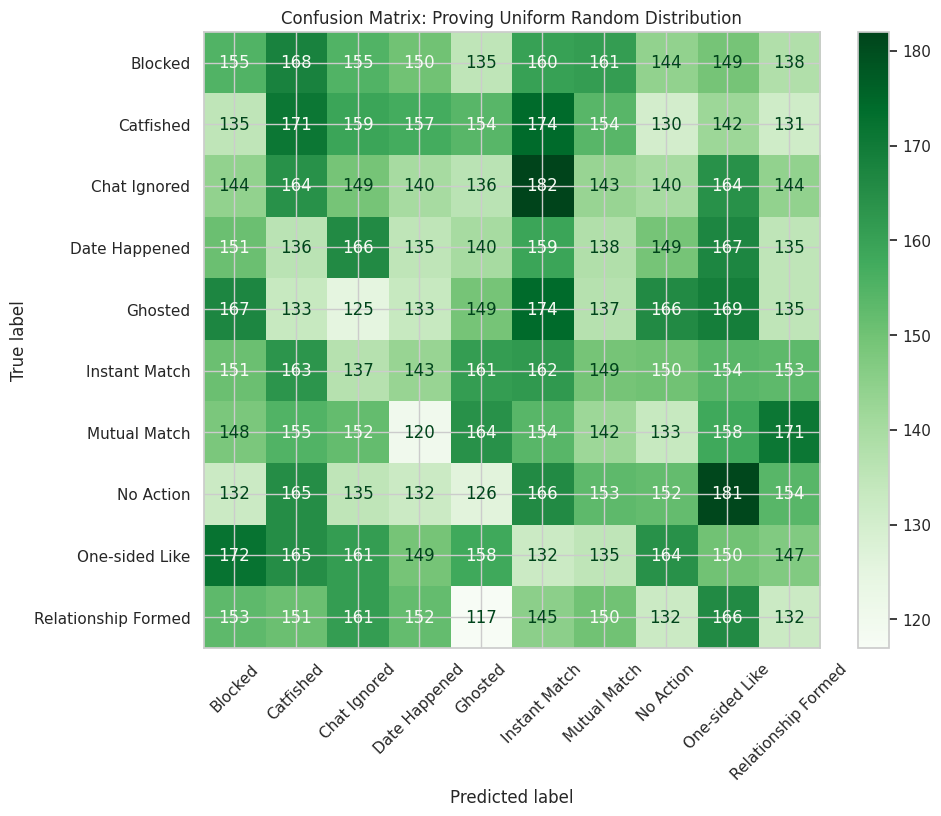

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Using LightGBM as the winner
final_model = trained_models['LightGBM']
y_pred = final_model.predict(X_test_mi_pd)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred,
    display_labels=le.classes_,
    xticks_rotation=45,
    cmap='Greens', # Use a single color to see if any cell stands out
    ax=ax
)
plt.title("Confusion Matrix: Proving Uniform Random Distribution")
plt.show()